In [1]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.callbacks import Callback
from datamodules import data_processors
from sklearn.preprocessing import StandardScaler
import sys
print(sys.version)

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


3.14.6 (main, Jun 10 2026, 10:03:53) [GCC 15.2.0]


In [2]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [3]:
N_archivos = 7
key_features = "x_"
path_rand = map(lambda x: "../input_data/cubic_" + str(x + 1) + ".csv", range(N_archivos))
datos_rand = [pd.read_csv(x) for x in path_rand]
path_to_current_model = "models/cubico_L4.keras" #"models/isotropico_act_custom_6.keras" # colocar "none" si quiere entrenar un modelo
if path_to_current_model == "none":
    new_model_path = "models/cubico_L5.keras"

In [4]:
if path_to_current_model == "none":
    class HistorySaverCallback(Callback):
        def __init__(self, filename=new_model_path[:-6] + "_save_history.csv"):
            super().__init__()
            self.filename = filename

            # Load existing history if file exists
            if os.path.exists(self.filename):
                self.history_df = pd.read_csv(self.filename)
            else:
                self.history_df = pd.DataFrame()

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}

            # Append new row
            logs['epoch'] = epoch
            self.history_df = pd.concat([self.history_df, pd.DataFrame([logs])], ignore_index=True)

            # Save to CSV
            self.history_df.to_csv(self.filename, index=False)

In [6]:
datos_rand[6].head()

,phi_a,x_K,eta,beta,phi_K,eig_0,eig_1,eig_2,eig_3,eig_4,...,eig_13,eig_14,eig_15,eig_16,eig_17,eig_18,eig_19,Parallelepiped,Cylinder,Ellipsoid
0,1.049676,0.708594,0.322259,0.513729,0.783293,0.000076,8.070899,16.256411,33.307853,51.517915,...,1429.555641,1489.126386,1517.052845,1733.441463,2178.112903,3214.676303,4648.550858,1,0,0
1,0.390669,0.642191,1.475150,2.849703,0.873444,0.718309,2.835920,2.992824,3.064935,3.260529,...,8.525260,10.005167,10.009817,10.471869,10.517483,11.087247,11.342480,1,0,0
2,0.911718,0.293442,1.813768,0.032888,1.272971,0.000017,1.092297,3.118207,5.229270,6.870611,...,135.820024,152.028311,298.473761,305.193785,335.060841,490.354772,490.771666,1,0,0
3,1.198472,0.966853,1.741133,2.609017,0.258194,0.725100,1.231787,1.602138,1.752686,1.856571,...,3.422933,3.983840,4.047991,4.070923,4.165933,4.216634,4.305407,1,0,0
4,1.481928,0.018932,1.191413,0.347279,1.551863,0.000585,6.238915,10.414149,14.065171,41.381859,...,161.739720,181.051307,187.497493,190.997747,245.566246,247.537704,366.046753,1,0,0


In [7]:
N_eig = 19
features = ["eta", "beta"] + list(map(lambda x: key_features + str(x), range(N_eig + 1)))
target = ["phi_a", "phi_K"]

In [8]:
datos_post = []
for datos in datos_rand:
    datos_post.append(data_processors.preprocess_data(datos, N_eig, target))
#fin for 
datos_rand = datos_post

In [9]:
total_datos = sum(map(lambda x: len(datos_rand[x]), range(len(datos_rand))))
print({"total datos": total_datos})

{'total datos': 349945}


In [10]:
datos_rand[6].head()

,phi_a,phi_K,eig_0,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
0,0.668244,0.498660,0.000076,0.322259,0.513729,0.123902,0.496475,0.488065,0.646530,0.732631,...,0.036146,0.074610,0.031205,0.048074,0.012815,0.006008,0.046550,0.095658,0.222986,0.308456
1,0.248708,0.556051,0.718309,1.475150,2.849703,0.352619,0.947573,0.976472,0.940011,0.908366,...,0.017010,0.079322,0.011962,0.013526,0.130475,0.000410,0.040736,0.004021,0.050233,0.022502
2,0.580418,0.810398,0.000017,1.813768,0.032888,0.915502,0.350296,0.596299,0.761107,0.716932,...,0.008884,0.131559,0.007486,0.058862,0.033026,0.298398,0.013693,0.060857,0.316428,0.000849
3,0.762971,0.164371,0.725100,1.741133,2.609017,0.811828,0.768840,0.914105,0.944045,0.866541,...,0.017059,0.002216,0.175654,0.023018,0.130280,0.014900,0.005326,0.022068,0.011776,0.020619
4,0.943424,0.987947,0.000585,1.191413,0.347279,0.160284,0.599081,0.740421,0.339887,0.974154,...,0.127075,0.014162,0.078582,0.040791,0.052757,0.017610,0.009562,0.149075,0.005386,0.323754


In [11]:
datos_rand[0].keys()

Index(['phi_a', 'phi_K', 'eig_0', 'eta', 'beta', 'eig_1', 'eig_2', 'eig_3',
       'eig_4', 'eig_5', 'eig_6', 'eig_7', 'eig_8', 'eig_9', 'eig_10',
       'eig_11', 'eig_12', 'eig_13', 'eig_14', 'eig_15', 'eig_16', 'eig_17',
       'eig_18', 'eig_19', 'x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6',
       'x_7', 'x_8', 'x_9', 'x_10', 'x_11', 'x_12', 'x_13', 'x_14', 'x_15',
       'x_16', 'x_17', 'x_18', 'x_19'],
      dtype='str')

In [12]:
#X_rand = pd.concat(datos_rand[x][features] for x in range(N_archivos))
#y_rand = pd.concat(datos_rand[x][target] for x in range(N_archivos))
datos_rand_full = pd.concat(datos_rand[x][target + features] for x in range(N_archivos))

In [13]:
datos_rand_full.head()

,phi_a,phi_K,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
0,0.537095,0.551652,1.577259,1.574131,0.052876,0.070917,0.033923,0.072135,0.010399,0.007201,...,0.044254,0.003605,0.062714,0.011232,0.035921,0.065271,0.024853,0.020300,0.224037,0.087339
1,0.394011,0.860056,1.216162,1.820191,0.063830,0.004432,0.072088,0.109371,0.001391,0.050202,...,0.036307,0.021216,0.141992,0.012995,0.000691,0.014469,0.197436,0.022863,0.026711,0.020965
2,0.048942,0.841777,1.434582,2.036289,0.038015,0.107686,0.035182,0.037042,0.002828,0.078957,...,0.024378,0.078955,0.079060,0.006715,0.012978,0.030880,0.005818,0.143328,0.202825,0.030601
3,0.929222,0.653809,1.481719,1.376496,0.051567,0.058937,0.025695,0.007112,0.015927,0.054878,...,0.023561,0.006362,0.055864,0.047249,0.092141,0.060143,0.006323,0.051674,0.191972,0.032072
4,0.020696,0.203180,1.839938,0.803203,0.009433,0.085480,0.036802,0.009753,0.022717,0.070989,...,0.060522,0.001708,0.122370,0.014358,0.135893,0.020733,0.038792,0.156920,0.039106,0.079716


In [14]:
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15
datos_rand_shuffled = datos_rand_full.sample(frac = 1, random_state = 42)

In [15]:
n_tot = len(datos_rand_shuffled)
train_end = int(train_frac * n_tot)
val_end = train_end + int(val_frac * n_tot)
datos_train = datos_rand_shuffled.iloc[:train_end]
datos_val = datos_rand_shuffled.iloc[train_end:val_end]
datos_test = datos_rand_shuffled.iloc[val_end:]

In [16]:
print("Train: ", len(datos_train))
print("Val: ", len(datos_val))
print("Test: ", len(datos_test))

Train:  244961
Val:  52491
Test:  52493


In [17]:
X_train = datos_train[features]
y_train = datos_train[target]
X_val = datos_val[features]
y_val = datos_val[target]
X_test = datos_test[features]
y_test = datos_test[target]

In [18]:
X_train.head()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
25797,1.843061,1.118827,0.066329,0.011459,0.068832,0.035167,0.089494,0.020570,0.027101,0.035497,...,0.034363,0.034600,0.207583,0.042422,0.000141,0.148000,0.015260,0.022411,0.059343,0.059057
27109,0.838728,0.868947,0.006012,0.009894,0.021433,0.050908,0.004721,0.034110,0.028563,0.098984,...,0.021350,0.023760,0.135051,0.005782,0.202342,0.023572,0.028367,0.014200,0.242617,0.006317
30326,1.685468,1.488334,0.047290,0.124949,0.024790,0.012947,0.055793,0.020172,0.029594,0.040973,...,0.020610,0.011865,0.034925,0.032483,0.035563,0.041728,0.074899,0.042234,0.113096,0.052506
22310,1.270419,1.532502,0.021258,0.112393,0.018302,0.020151,0.015165,0.163256,0.015149,0.021174,...,0.042951,0.077064,0.031492,0.004067,0.163425,0.054064,0.010139,0.017415,0.029419,0.142069
36047,1.316925,2.718949,0.047435,0.009391,0.018204,0.074494,0.041306,0.020335,0.001688,0.042258,...,0.071620,0.034793,0.016523,0.200177,0.094900,0.078159,0.011317,0.029732,0.003406,0.019541


In [19]:
X_train.describe()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
count,244961.000000,244961.000000,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,...,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05,2.449610e+05
mean,1.187928,1.572890,4.186211e-02,3.342433e-02,3.068675e-02,3.656490e-02,2.760091e-02,3.209943e-02,3.517117e-02,4.680360e-02,...,5.105314e-02,6.068900e-02,5.631030e-02,5.477762e-02,6.281630e-02,5.752476e-02,6.298223e-02,6.591096e-02,7.662435e-02,8.653353e-02
std,0.461008,0.907552,5.269425e-02,4.028936e-02,2.878632e-02,3.799152e-02,3.126059e-02,3.194305e-02,3.477146e-02,4.966806e-02,...,5.259976e-02,5.911499e-02,5.520528e-02,5.237657e-02,6.005073e-02,5.568217e-02,6.384399e-02,6.679583e-02,7.457094e-02,1.000160e-01
min,0.005091,0.000230,1.439591e-08,3.438947e-11,1.180504e-08,7.269378e-08,9.645130e-08,1.272049e-07,3.292897e-07,5.362090e-07,...,3.788087e-07,2.512846e-07,1.721024e-07,2.485920e-07,7.585699e-08,3.744762e-07,4.310524e-07,3.492429e-08,4.137779e-07,5.733872e-07
25%,0.843803,0.788271,5.255080e-03,4.352730e-03,7.321206e-03,7.914250e-03,6.593431e-03,8.687340e-03,1.006540e-02,1.143064e-02,...,1.395248e-02,1.686462e-02,1.612513e-02,1.585443e-02,1.768640e-02,1.625035e-02,1.738658e-02,1.850607e-02,2.164186e-02,2.244240e-02
50%,1.234461,1.573603,2.246540e-02,1.621666e-02,2.186852e-02,2.348170e-02,1.809120e-02,2.183056e-02,2.482082e-02,3.082695e-02,...,3.385252e-02,4.219943e-02,3.933988e-02,3.898120e-02,4.392628e-02,4.032448e-02,4.201881e-02,4.526569e-02,5.297040e-02,5.629090e-02
75%,1.574875,2.360393,5.860979e-02,4.708713e-02,4.702911e-02,5.318396e-02,3.806009e-02,4.522272e-02,4.958872e-02,6.646230e-02,...,6.943872e-02,8.641384e-02,7.896573e-02,7.779240e-02,9.059170e-02,8.175295e-02,8.745288e-02,9.176241e-02,1.080178e-01,1.146941e-01
max,1.916365,3.141580,5.471063e-01,1.999947e-01,2.589927e-01,3.219056e-01,3.431857e-01,2.545989e-01,3.942665e-01,3.817601e-01,...,4.417378e-01,4.609061e-01,5.115809e-01,6.136433e-01,5.436618e-01,4.840194e-01,7.189940e-01,6.888602e-01,8.164860e-01,7.727486e-01


In [20]:
estadisticas = pd.DataFrame(X_train.describe())
if path_to_current_model == "none":
    estadisticas.to_csv(new_model_path[:-6] + "_stats.csv")

In [21]:
X_train = data_processors.scale(X_train)
X_train.head()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
25797,1.421091,-0.500318,0.464314,-0.545192,1.325109,-0.036792,1.979914,-0.360932,-0.232090,-0.227636,...,-0.317300,-0.441322,2.740193,-0.235907,-1.043709,1.624862,-0.747487,-0.651239,-0.231739,-0.274721
27109,-0.757471,-0.775651,-0.680337,-0.584045,-0.321465,0.377535,-0.731899,0.062936,-0.190034,1.050579,...,-0.564707,-0.624700,1.426330,-0.935451,2.323470,-0.609761,-0.542180,-0.774173,2.225978,-0.802034
30326,1.079245,-0.093170,0.103012,2.271700,-0.204841,-0.621655,0.901837,-0.373410,-0.160390,-0.117386,...,-0.578778,-0.825914,-0.387379,-0.425654,-0.453843,-0.283695,0.186651,-0.354475,0.489092,-0.340222
22310,0.178938,-0.044502,-0.391013,1.960046,-0.430236,-0.432033,-0.397826,4.105950,-0.575824,-0.516018,...,-0.154031,0.277005,-0.449559,-0.968186,1.675401,-0.062150,-0.827701,-0.726034,-0.633032,0.555271
36047,0.279816,1.262804,0.105768,-0.596515,-0.433639,0.998363,0.438411,-0.368307,-0.962950,-0.091527,...,0.391012,-0.438058,-0.720710,2.776036,0.534278,0.370565,-0.809241,-0.541636,-0.981858,-0.669820


In [22]:
X_val = data_processors.scale(X_val, estadisticas)
X_val.head()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
14435,0.570212,1.277921,0.903188,2.482356,-0.012535,-0.436325,0.894073,-0.337162,-0.082697,0.901987,...,-0.577107,0.406225,-0.897072,-0.915959,1.797238,-0.788317,-0.928220,0.089545,-0.862050,-0.619973
32945,0.429376,-1.596046,-0.777569,-0.675899,-0.909970,-0.801199,-0.817359,-0.247828,-0.415045,-0.889183,...,0.285615,-0.251112,0.002577,0.621006,0.937301,-0.470610,0.462585,1.136823,-0.918673,1.234997
6308,-1.425568,1.512942,-0.708645,-0.809866,-0.177646,-0.860886,-0.829464,-0.505962,0.460135,-0.759899,...,0.366179,2.205182,-0.345306,-0.918620,-0.559795,-0.014043,0.109896,0.261803,0.274053,0.485941
42646,0.184982,-0.922978,-0.425601,-0.692039,1.359737,-0.822036,0.302162,1.267048,-0.897236,0.859918,...,-0.731475,2.003797,-0.849006,-0.778640,0.264465,-0.587022,0.389398,-0.477166,-0.259862,0.707029
27265,1.163489,0.529712,0.406116,2.355378,1.905492,-0.449335,-0.839894,0.699924,-0.716960,-0.851352,...,-0.940295,2.489827,0.842043,-0.814001,-0.786249,2.099073,-0.655109,-0.056463,-0.997418,-0.611866


In [23]:
X_test = data_processors.scale(X_test, estadisticas)
X_test.head()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
41491,-1.300116,0.638602,-0.633845,-0.561614,-0.762445,-0.262888,0.452598,-0.891444,-0.459162,0.165191,...,1.102953,3.216114,0.448344,-0.111055,0.610397,-0.605366,-0.961127,0.142573,-0.658003,-0.804438
38845,1.108225,1.141607,4.037984,-0.505055,0.664468,0.386407,0.781945,-0.794582,1.240732,0.230872,...,-0.677947,-0.937721,1.009274,-0.126956,-1.043754,-0.710702,-0.640006,-0.459814,-0.307759,0.104546
39792,-0.412099,1.450465,-0.090232,-0.678890,0.721435,2.442502,-0.369302,1.306110,2.104792,-0.620374,...,-0.284865,-0.070645,-0.273103,-0.670960,0.722789,-0.707588,-0.203568,-0.803660,0.817449,-0.437811
3659,0.433328,-0.871021,-0.665993,0.164989,-0.977639,-0.273440,-0.675456,-0.832063,0.080049,-0.055991,...,-0.077111,-0.357317,-0.887398,1.733874,-0.333853,-0.015830,0.112889,-0.471627,0.154400,1.562333
16934,0.150952,-0.676575,-0.317586,-0.377795,1.880872,-0.430952,1.306695,-0.908165,0.074153,-0.132450,...,-0.822388,1.863811,0.243645,0.343629,-0.741825,-0.736585,-0.124021,-0.742063,-0.033717,-0.105633


In [24]:
corr_mat = datos_train.select_dtypes(include=['number']).corr()
print(corr_mat)

          phi_a     phi_K       eta      beta       x_0       x_1       x_2  \
phi_a  1.000000 -0.000820 -0.002794 -0.001381  0.144046 -0.324579 -0.019630   
phi_K -0.000820  1.000000  0.001486 -0.001048  0.010958 -0.145882 -0.038757   
eta   -0.002794  0.001486  1.000000 -0.002931  0.523359  0.490697  0.394133   
beta  -0.001381 -0.001048 -0.002931  1.000000  0.578032  0.325630  0.163734   
x_0    0.144046  0.010958  0.523359  0.578032  1.000000  0.379701  0.319084   
x_1   -0.324579 -0.145882  0.490697  0.325630  0.379701  1.000000  0.182659   
x_2   -0.019630 -0.038757  0.394133  0.163734  0.319084  0.182659  1.000000   
x_3    0.107732 -0.030489  0.196090  0.404057  0.358196  0.054600  0.031286   
x_4    0.098127  0.034985  0.133294  0.351540  0.359422  0.052409  0.158021   
x_5   -0.098032 -0.042060  0.219369  0.011310  0.063163  0.168290  0.164306   
x_6    0.087761  0.005109  0.032198  0.250527  0.075562  0.052248  0.114915   
x_7   -0.033169 -0.053461  0.000680  0.314074  0.131

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


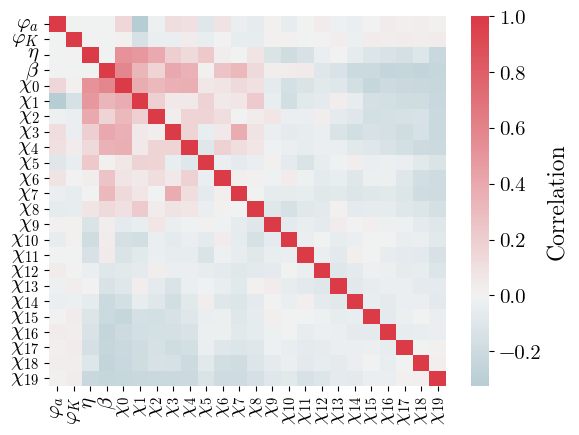

In [25]:
symbols_target = {"phi_a": r"$\varphi_a$", "phi_K": r"$\varphi_K$"}
symbols_comp = dict(map(lambda x: ("x_" + str(x), r"$\chi_{%d}$" % x), range(N_eig + 1)))
symbols_features = {**symbols_target, "eta": r"$\eta$", "beta": r"$\beta$", **symbols_comp}
ax_2 = sns.heatmap(corr_mat, cmap=sns.diverging_palette(220, 10, as_cmap=True), xticklabels = symbols_features.values(), yticklabels = symbols_features.values(), center=0,
    cbar_kws={"label": "Correlation"})
cbar_ax = ax_2.collections[0].colorbar.ax
cbar_ax.tick_params(labelsize=15)
cbar_ax.yaxis.label.set_size(17)
ax_2.tick_params(axis='x', labelsize=15)
ax_2.tick_params(axis='y', labelsize=15)
plt.savefig("../Thesis_Docs/pictures/fig27.pdf", bbox_inches="tight", pad_inches=0)

In [26]:
torch.cuda.get_device_properties(torch.device("cuda"))

_CudaDeviceProperties(name='AMD Radeon RX 6600M', major=10, minor=3, gcnArchName='gfx1030', total_memory=8176MB, multi_processor_count=14, uuid=58580000-0000-0000-0000-000000000000, L2_cache_size=2MB)

In [27]:
def crear_modelo_de_regresion(lr_var, n_input_data, def_act = 'relu'):    
    modelo = keras.models.Sequential()
    modelo.add(keras.layers.Dense(256, activation = def_act, input_shape = (n_input_data,)))
    modelo.add(keras.layers.Dense(1024, activation = def_act))
    modelo.add(keras.layers.Dense(1400, activation = def_act))
    modelo.add(keras.layers.Dense(2490, activation = def_act))
    modelo.add(keras.layers.Dense(6333, activation = def_act))
    modelo.add(keras.layers.Dense(6295, activation = def_act))
    modelo.add(keras.layers.Dense(2566, activation = def_act))
    modelo.add(keras.layers.Dense(2004, activation = def_act))
    modelo.add(keras.layers.Dense(1086, activation = def_act))
    modelo.add(keras.layers.Dense(700, activation = def_act))
    modelo.add(keras.layers.Dense(384, activation = def_act))
    modelo.add(keras.layers.Dense(64, activation = def_act))
    modelo.add(keras.layers.Dense(2, activation = 'hard_sigmoid'))
    modelo.compile(optimizer = keras.optimizers.Adam(learning_rate = lr_var), loss = 'mse', metrics = ['mae']) #RMSprop
    return modelo

In [28]:
X_val.head()

,eta,beta,x_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,...,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19
27831,0.884341,-0.563213,-0.154366,0.257319,-0.401862,0.941163,-0.884795,1.249869,-0.371478,-0.811046,...,-0.849303,-1.056624,-1.013758,0.545518,-0.785760,-0.608890,1.939953,-0.906637,1.013352,0.156804
31787,-0.056201,1.714318,0.195264,1.396849,-1.114193,0.947395,0.018367,-0.977559,1.671883,1.384305,...,-1.004659,-1.084140,0.650935,-0.914940,1.070593,-0.996686,2.405045,-0.745870,-0.772912,-0.935093
27279,-0.320113,0.271602,-0.112749,0.440814,-1.012939,1.255614,0.041534,2.698119,-0.754002,-0.874800,...,-0.606486,-0.469917,-0.741231,0.469954,-0.744107,1.204162,-0.784021,0.116212,-0.438881,-0.787821
3898,1.549112,-0.142839,0.604030,0.519414,-0.698542,0.011415,0.024957,1.203689,-0.857985,-0.209118,...,-0.398823,-0.418743,-0.590568,2.367049,0.735245,-0.873655,-0.933925,0.023971,-0.546168,0.373429
3399,-0.586558,-0.703100,-0.626542,-0.491713,0.590487,-0.549603,-0.361670,0.838146,-0.323845,0.055680,...,0.654286,1.642401,1.471706,-0.175395,0.316642,-0.149078,-0.874818,-0.617281,-0.308038,0.640656


In [30]:
if path_to_current_model == "none":
    history_saver = HistorySaverCallback(new_model_path[:-6] + "_save_history.csv")

In [32]:
epocas = 100
if path_to_current_model == "none":
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        new_model_path,  
        save_best_only=True,
        save_weights_only=False, 
    )

In [33]:
if path_to_current_model == "none":
    path_model = new_model_path
    try:
        modelo = keras.models.load_model(path_model)
    except: 
        modelo = crear_modelo_de_regresion(0.0005, len(features))
    #fin exception
    history = modelo.fit(X_train, y_train, epochs = epocas, batch_size=320, 
                            validation_data = (X_val, y_val), callbacks=[checkpoint_callback, history_saver])
else:
    modelo = keras.models.load_model(path_to_current_model)
#fin if 

In [34]:
mets_train = data_processors.get_metrics(X_train, y_train, modelo)
mets_val = data_processors.get_metrics(X_val, y_val, modelo)
mets_rand1 = data_processors.get_metrics(X_test, y_test, modelo)

    6/26247 ━━━━━━━━━━━━━━━━━━━━ 5:10 12ms/step    

/home/cubos/.local/lib/python3.13/site-packages/keras/src/backend/torch/numpy.py:114: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:328.)
  return cast(torch.matmul(x1, x2), result_dtype)


26247/26247 ━━━━━━━━━━━━━━━━━━━━ 250s 10ms/step
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 54s 10ms/step
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 54s 10ms/step


In [35]:
print("Train: ", mets_train)
print("Val: ", mets_val)
print("Test: ", mets_rand1)

Train:  {'R2': 0.9772669076919556, 'RMSE': 0.03339700773358345, 'MAE': 0.016174186021089554, 'SDAE': np.float64(0.2303703654498213)}
Val:  {'R2': 0.9273912906646729, 'RMSE': 0.060576170682907104, 'MAE': 0.026156581938266754, 'SDAE': np.float64(0.23042040875594358)}
Test:  {'R2': 0.9269522428512573, 'RMSE': 0.06095396727323532, 'MAE': 0.026238488033413887, 'SDAE': np.float64(0.2301341846040638)}


In [31]:
if path_to_current_model == "none":
    modelo.save(new_model_path[:-6] + "_final.keras")
    #modelo.save("models/cubico_L5_final.keras")
#fin if 

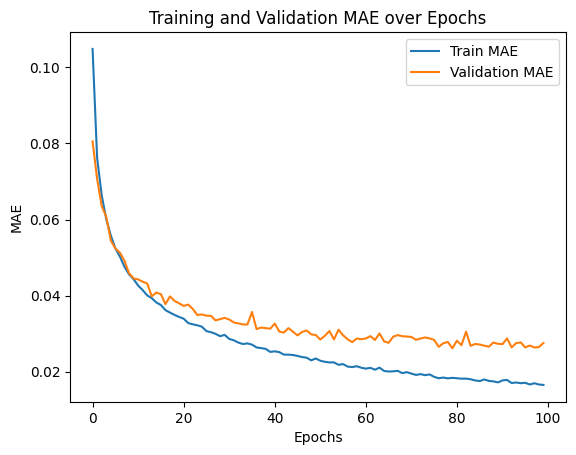

In [32]:
if path_to_current_model == "none":
    train_mae = history.history["mae"]
    val_mae = history.history["val_mae"]
    plt.figure()
    plt.plot(train_mae, label='Train MAE')
    plt.plot(val_mae, label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training and Validation MAE over Epochs')
    plt.legend()

In [33]:
if path_to_current_model == "none":
    import json
    with open(new_model_path[:-6] +'_history.json', 'w') as f:
        json.dump(history.history, f)